In [1]:
%load_ext cython

In [2]:
# ============================================================================
# CELL 1: LLM Query Function
# ============================================================================

import requests
import json

def get_strategy_from_llm(iteration):
    """
    Queries the local Ollama Llama3:8b model to suggest an optimization strategy.
    
    Args:
        iteration (int): The current iteration number of the algorithm.
        
    Returns:
        int: The chosen strategy number (1-5).
    """
    prompt = f"""Select strategy for knapsack optimization iteration {iteration}/100.

Phase: {"Early" if iteration < 20 else "Mid" if iteration < 60 else "Late" if iteration < 90 else "Final"}

Strategies:
1 = Balanced exploration (early phase, need diversity)
2 = Objective specialization (mid phase, extreme solutions)
3 = Gap filling (always good, improve weak objective)
4 = Aggressive exploitation (late phase, high quality only)
5 = Random perturbation (if stuck)

Reply with ONE number (1-5):"""

    url = "http://localhost:11434/api/generate"
    payload = {
        "model": "llama3:8b",
        "prompt": prompt,
        "stream": False,
        "options": {
            "temperature": 0.7,
            "max_tokens": 10
        }
    }
    
    try:
        response = requests.post(url, json=payload, timeout=40)
        if response.status_code == 200:
            result = response.json()
            response_text = result.get('response', '')
            for char in response_text:
                if char.isdigit():
                    strategy = int(char)
                    return min(max(strategy, 1), 5)
            print(f"Warning: LLM response '{response_text}' did not contain a number. Defaulting to strategy 1.")
            return 1
        else:
            print(f"Error connecting to Ollama: {response.status_code} - {response.text}")
            return 1
    except requests.exceptions.RequestException as e:
        print(f"Error getting strategy from LLM: {e}. Is Ollama running?")
        return 1

# Test the function
print("Testing LLM connection...")
strategy = get_strategy_from_llm(50)
print(f"LLM suggested strategy: {strategy}")

Testing LLM connection...
LLM suggested strategy: 2


In [3]:
%%cython
# ============================================================================
# HYBRID LLM-MOACP - COMPLETE FIXED VERSION
# Date: 2025-11-05 19:55:01 UTC
# User: samimh23
# ============================================================================

from libc.stdlib cimport malloc, free, srand, rand
from libc.string cimport memset
from libc.math cimport exp
import time

cdef struct ind:
    int nombr_nonpris
    int nombr
    int rank
    float fitnessbest
    float fitness
    int explored
    double *f
    double *capa
    double *v
    int *d
    int *Items

cdef struct pop:
    int size
    int maxsize
    ind **ind_array

# ============================================================================
# GLOBAL VARIABLES
# ============================================================================

cdef int NBITEMS = 250
cdef int ni = 250
cdef int L = 5
cdef double LARGE = 10e50
cdef float smallValue = 0.0000001
cdef double kappa = 0.05
cdef int alpha = 10
cdef int paretoIni = 28000

cdef int nf = 2
cdef double *capacities = NULL
cdef int **weights = NULL
cdef int **profits = NULL
cdef double *vector_weight = NULL
cdef double max_bound = 0.0
cdef double **OBJ_Weights = NULL
cdef int nombreLIGNE = 0
cdef int nextLn = 0
cdef int inv = 0
cdef int OBJ_Weights_lines = 0

# Statistics
cdef long long llm_strategy_calls = 0
cdef int current_iteration = 0

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def seed(int x):
    srand(x)

cdef int irand(int range_val):
    return rand() % range_val

cdef void *chk_malloc(size_t size):
    cdef void *return_value = malloc(size)
    if return_value == NULL:
        raise MemoryError("Out of memory.")
    memset(return_value, 0, size)
    return return_value

# ============================================================================
# POPULATION MANAGEMENT
# ============================================================================

cdef pop *create_pop(int maxsize, int nf):
    cdef int i
    cdef pop *pp = <pop *>chk_malloc(sizeof(pop))
    pp.size = 0
    pp.maxsize = maxsize
    pp.ind_array = <ind **>chk_malloc(maxsize * sizeof(void*))
    for i in range(maxsize):
        pp.ind_array[i] = NULL
    return pp

cdef ind *create_ind(int nf):
    cdef int i
    cdef ind *p_ind = <ind *>chk_malloc(sizeof(ind))
    p_ind.nombr_nonpris = 0
    p_ind.nombr = 0
    p_ind.rank = 0
    p_ind.fitnessbest = -1.0
    p_ind.fitness = -1.0
    p_ind.explored = 0
    p_ind.f = <double *>chk_malloc(nf * sizeof(double))
    p_ind.capa = <double *>chk_malloc(nf * sizeof(double))
    p_ind.v = <double *>chk_malloc(nf * sizeof(double))
    p_ind.d = <int *>chk_malloc(ni * sizeof(int))
    p_ind.Items = <int *>chk_malloc(ni * sizeof(int))
    for i in range(ni):
        p_ind.Items[i] = 0
        p_ind.d[i] = 0
    for i in range(nf):
        p_ind.f[i] = 0.0
        p_ind.capa[i] = 0.0
        p_ind.v[i] = 0.0
    return p_ind

cdef ind *ind_copy(ind *i):
    cdef ind *p_ind = create_ind(nf)
    cdef int k
    p_ind.nombr_nonpris = i.nombr_nonpris
    p_ind.nombr = i.nombr
    p_ind.rank = i.rank
    p_ind.fitnessbest = i.fitnessbest
    p_ind.fitness = i.fitness
    p_ind.explored = i.explored
    for k in range(nf):
        p_ind.f[k] = i.f[k]
        p_ind.v[k] = i.v[k]
        p_ind.capa[k] = i.capa[k]
    for k in range(ni):
        p_ind.d[k] = i.d[k]
        p_ind.Items[k] = i.Items[k]
    return p_ind

cdef void free_ind(ind *p_ind):
    if p_ind != NULL:
        free(p_ind.d)
        free(p_ind.f)
        free(p_ind.capa)
        free(p_ind.v)
        free(p_ind.Items)
        free(p_ind)

cdef void complete_free_pop(pop *pp):
    cdef int i
    if pp != NULL:
        if pp.ind_array != NULL:
            for i in range(pp.size):
                if pp.ind_array[i] != NULL:
                    free_ind(pp.ind_array[i])
                    pp.ind_array[i] = NULL
            free(pp.ind_array)
        free(pp)

cdef void cleanup_globals():
    global capacities, weights, profits, vector_weight, OBJ_Weights, OBJ_Weights_lines, nf, ni
    cdef int i
    if capacities != NULL:
        free(capacities)
        capacities = NULL
    if weights != NULL:
        for i in range(nf):
            if weights[i] != NULL:
                free(weights[i])
        free(weights)
        weights = NULL
    if profits != NULL:
        for i in range(nf):
            if profits[i] != NULL:
                free(profits[i])
        free(profits)
        profits = NULL
    if vector_weight != NULL:
        free(vector_weight)
        vector_weight = NULL
    if OBJ_Weights != NULL:
        for i in range(nf):
            if OBJ_Weights[i] != NULL:
                free(OBJ_Weights[i])
        free(OBJ_Weights)
        OBJ_Weights = NULL
    OBJ_Weights_lines = 0
    nf = 0
    ni = 0

# ============================================================================
# PARETO DOMINANCE
# ============================================================================

cdef int non_dominated(ind *p_ind_a, ind *p_ind_b):
    cdef int i
    cdef int a_is_good = -1
    cdef int equal = 1
    for i in range(nf):
        if p_ind_a.f[i] > p_ind_b.f[i]:
            a_is_good = 1
        if p_ind_a.f[i] != p_ind_b.f[i]:
            equal = 0
    if equal:
        return 0
    return a_is_good

# ============================================================================
# EPSILON INDICATOR & FITNESS
# ============================================================================

cdef double calcAddEpsIndicator(ind *p_ind_a, ind *p_ind_b):
    global max_bound
    cdef int i
    cdef double eps
    cdef double temp_eps
    if max_bound == 0.0:
        max_bound = 1e-8
    eps = (p_ind_a.v[0]/max_bound)-(p_ind_b.v[0]/max_bound)
    for i in range(1, nf):
        temp_eps = (p_ind_a.v[i]/max_bound)-(p_ind_b.v[i]/max_bound)
        if temp_eps > eps:
            eps = temp_eps
    return eps

cdef void init_fitness(ind *x):
    x.fitness = 0.0

cdef void update_fitness(ind *x, double I):
    x.fitness -= exp(-I / kappa)

cdef double update_fitness_return(double f, double I):
    return f - exp(-I / kappa)

cdef int delete_fitness(ind *x, double I):
    x.fitness += exp(-I / kappa)
    return 0

cdef void compute_ind_fitness(ind *x, pop *SP):
    cdef int j
    init_fitness(x)
    for j in range(SP.size):
        if SP.ind_array[j] != x:
            update_fitness(x, calcAddEpsIndicator(SP.ind_array[j], x))

cdef void compute_all_fitness(pop *SP):
    cdef int i
    for i in range(SP.size):
        compute_ind_fitness(SP.ind_array[i], SP)

# ============================================================================
# FILE I/O
# ============================================================================

cdef void loadMOKP(char *filename):
    global nf, ni, capacities, weights, profits
    cdef int i, f
    with open(filename.decode(), "r") as source:
        _nf, _ni = [int(x) for x in source.readline().split()]
        nf = _nf
        ni = _ni
        capacities = <double *>chk_malloc(nf * sizeof(double))
        weights = <int **>chk_malloc(nf * sizeof(void*))
        profits = <int **>chk_malloc(nf * sizeof(void*))
        for f in range(nf):
            capacities[f] = float(source.readline().strip())
            weights[f] = <int *>chk_malloc(ni * sizeof(int))
            profits[f] = <int *>chk_malloc(ni * sizeof(int))
            for i in range(ni):
                source.readline()
                weights[f][i] = int(source.readline().strip())
                profits[f][i] = int(source.readline().strip())

cdef void read_weights_file(char *filename):
    global OBJ_Weights, nombreLIGNE, nf, OBJ_Weights_lines
    cdef int i, j, nlines
    with open(filename.decode(), "r") as f:
        lines = [line for line in f if line.strip()]
    nlines = len(lines)
    OBJ_Weights = <double **>chk_malloc(nf * sizeof(void*))
    for i in range(nf):
        OBJ_Weights[i] = <double *>chk_malloc(nlines * sizeof(double))
    for i, line in enumerate(lines):
        vals = line.strip().split()
        for j in range(nf):
            OBJ_Weights[j][i] = float(vals[j])
    nombreLIGNE = nlines - 1
    OBJ_Weights_lines = nlines

cdef void dynamic_weight_allpop():
    global vector_weight, OBJ_Weights, nombreLIGNE, nf, nextLn
    cdef int i
    if vector_weight == NULL:
        vector_weight = <double *>chk_malloc(nf * sizeof(double))
    for i in range(nf):
        vector_weight[i] = OBJ_Weights[i][nextLn]
    if nextLn == nombreLIGNE:
        nextLn = 0
    else:
        nextLn += 1

cdef void choose_weight():
    dynamic_weight_allpop()

# ============================================================================
# INITIALIZATION & EVALUATION
# ============================================================================

cdef void random_init_ind(ind *x):
    cdef int j, r, tmp
    for j in range(ni):
        x.d[j] = j
    for j in range(ni):
        r = irand(ni)
        tmp = x.d[r]
        x.d[r] = x.d[j]
        x.d[j] = tmp

cdef void evaluate(ind *x):
    cdef int j, l, k, faisable
    x.nombr = 0
    x.nombr_nonpris = 0
    for j in range(nf):
        x.capa[j] = 0.0
        x.f[j] = 0.0
    for j in range(ni):
        l = 0
        faisable = 1
        while l < nf and faisable == 1:
            if x.capa[l] + weights[l][x.d[j]] > capacities[l]:
                faisable = 0
            l += 1
        if faisable == 1:
            for k in range(nf):
                x.capa[k] += weights[k][x.d[j]]
                x.f[k] += profits[k][x.d[j]]
            x.Items[x.d[j]] = 1
            x.nombr += 1
        else:
            x.Items[x.d[j]] = 0
            x.nombr_nonpris += 1

cdef void P_init_pop(pop *SP, pop *Sarchive, int alpha):
    cdef int i, x, tmp, t
    t = max(alpha, Sarchive.size)
    cdef int* shuffle = <int *>chk_malloc(t * sizeof(int))
    for i in range(t):
        shuffle[i] = i
    for i in range(t):
        x = irand(alpha)
        tmp = shuffle[i]
        shuffle[i] = shuffle[x]
        shuffle[x] = tmp
    SP.size = alpha
    if Sarchive.size > alpha:
        for i in range(alpha):
            SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
    else:
        for i in range(alpha):
            if shuffle[i] < Sarchive.size:
                SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
            else:
                SP.ind_array[i] = create_ind(nf)
                random_init_ind(SP.ind_array[i])
                evaluate(SP.ind_array[i])
    free(shuffle)

# ============================================================================
# ARCHIVE MANAGEMENT
# ============================================================================

cdef int extractPtoArchive(pop *P, pop *archive):
    cdef int i, j, dom, t, convergence_rate
    t = archive.size + P.size
    archiveAndP = create_pop(t, nf)
    convergence_rate = 0
    for i in range(archive.size):
        archiveAndP.ind_array[i] = archive.ind_array[i]
    for i in range(P.size):
        archiveAndP.ind_array[i + archive.size] = ind_copy(P.ind_array[i])
    archiveAndP.size = t
    archive.size = 0
    for i in range(t):
        for j in range(t):
            if i != j:
                dom = non_dominated(archiveAndP.ind_array[i], archiveAndP.ind_array[j])
                if dom == -1 or (dom == 0 and i > j):
                    break
        else:
            archive.ind_array[archive.size] = ind_copy(archiveAndP.ind_array[i])
            archive.size += 1
            if i >= t - P.size:
                convergence_rate += 1
    complete_free_pop(archiveAndP)
    return convergence_rate

cdef double calcMaxbound(pop *SP, int size):
    global max_bound
    cdef int i, j
    SP.size = size
    cdef double max_b = SP.ind_array[0].v[0]
    for i in range(SP.size):
        for j in range(nf):
            if max_b < SP.ind_array[i].v[j]:
                max_b = SP.ind_array[i].v[j]
    if max_b == 0.0:
        max_b = 1e-8
    max_bound = max_b
    return max_bound

cdef void calcul_weight(pop *SP, int size):
    cdef int i, j
    for i in range(SP.size):
        for j in range(nf):
            SP.ind_array[i].v[j] = SP.ind_array[i].f[j] * vector_weight[j]

# ============================================================================
# SELECTION
# ============================================================================

cdef int compute_fitness_and_select(pop *SP, ind *x, int size):
    cdef int i, worst
    cdef double worst_fit, fit_tmp
    SP.size = size
    x.fitness = 0
    compute_ind_fitness(x, SP)
    worst_fit = x.fitness
    worst = -1
    for i in range(SP.size):
        fit_tmp = update_fitness_return(SP.ind_array[i].fitness, calcAddEpsIndicator(x, SP.ind_array[i]))
        if fit_tmp > worst_fit:
            worst = i
            worst_fit = fit_tmp
    fit_tmp = x.fitness
    if worst == -1:
        return -1
    else:
        for i in range(SP.size):
            delete_fitness(SP.ind_array[i], calcAddEpsIndicator(SP.ind_array[worst], SP.ind_array[i]))
            update_fitness(SP.ind_array[i], calcAddEpsIndicator(x, SP.ind_array[i]))
        delete_fitness(x, calcAddEpsIndicator(SP.ind_array[worst], x))
        free_ind(SP.ind_array[worst])
        SP.ind_array[worst] = ind_copy(x)
        if fit_tmp - worst_fit > smallValue:
            return worst
        else:
            return -1

# ============================================================================
# FAST SAMPLING-BASED STRATEGY EXECUTION FUNCTIONS
# ============================================================================

cdef list balanced_exploration(ind *x, int L_val):
    """Balanced efficiency across objectives (FAST SAMPLING)"""
    cdef list scores = []
    cdef int item, k, attempts
    cdef double eff1, eff2, mean_eff, balance, score
    cdef int feasible
    cdef int max_attempts = 50
    
    attempts = 0
    while len(scores) < max_attempts and attempts < max_attempts * 3:
        item = irand(ni)
        attempts += 1
        
        if x.Items[item] == 0:
            feasible = 1
            for k in range(nf):
                if x.capa[k] + weights[k][item] > capacities[k]:
                    feasible = 0
                    break
            if feasible:
                eff1 = profits[0][item] / (weights[0][item] + 1.0)
                eff2 = profits[1][item] / (weights[1][item] + 1.0)
                mean_eff = (eff1 + eff2) / 2.0
                balance = min(eff1, eff2) / (max(eff1, eff2) + 1e-8)
                score = mean_eff * (0.7 + 0.3 * balance)
                scores.append((score, item))
    
    scores.sort(reverse=True)
    return [item for score, item in scores[:min(L_val, len(scores))]]

cdef list objective_specialization(ind *x, int L_val, int target_obj):
    """Prioritize one objective (FAST SAMPLING)"""
    cdef list scores = []
    cdef int item, other_obj, attempts
    cdef double target_eff, other_eff, score
    cdef int feasible
    cdef int max_attempts = 50

    other_obj = 1 - target_obj
    attempts = 0
    
    while len(scores) < max_attempts and attempts < max_attempts * 3:
        item = irand(ni)
        attempts += 1
        
        if x.Items[item] == 0:
            feasible = 1
            for k in range(nf):
                if x.capa[k] + weights[k][item] > capacities[k]:
                    feasible = 0
                    break
            if feasible:
                target_eff = profits[target_obj][item] / (weights[target_obj][item] + 1.0)
                other_eff = profits[other_obj][item] / (weights[other_obj][item] + 1.0)
                score = 0.9 * target_eff + 0.1 * other_eff
                scores.append((score, item))
    
    scores.sort(reverse=True)
    return [item for score, item in scores[:L_val]]

cdef list gap_filling(ind *x, int L_val):
    """Fill gaps by improving weakest objective (FAST SAMPLING)"""
    cdef list scores = []
    cdef int item, weakest_idx, attempts
    cdef double weak_eff, total_profit, score
    cdef int feasible
    cdef int max_attempts = 50

    weakest_idx = 0 if x.f[0] < x.f[1] else 1
    attempts = 0
    
    while len(scores) < max_attempts and attempts < max_attempts * 3:
        item = irand(ni)
        attempts += 1
        
        if x.Items[item] == 0:
            feasible = 1
            for k in range(nf):
                if x.capa[k] + weights[k][item] > capacities[k]:
                    feasible = 0
                    break
            if feasible:
                weak_eff = profits[weakest_idx][item] / (weights[weakest_idx][item] + 1.0)
                total_profit = profits[0][item] + profits[1][item]
                score = 0.7 * weak_eff + 0.3 * total_profit / 1000.0
                scores.append((score, item))
    
    scores.sort(reverse=True)
    return [item for score, item in scores[:L_val]]

cdef list aggressive_exploitation(ind *x, int L_val, double threshold):
    """Only high-quality items (FAST SAMPLING)"""
    cdef list scores = []
    cdef int item, attempts
    cdef double total_profit, total_weight, efficiency, current_avg
    cdef int feasible
    cdef int max_attempts = 50

    current_avg = (x.f[0] + x.f[1]) / (x.nombr + 1.0)
    attempts = 0
    
    while len(scores) < max_attempts and attempts < max_attempts * 3:
        item = irand(ni)
        attempts += 1
        
        if x.Items[item] == 0:
            feasible = 1
            for k in range(nf):
                if x.capa[k] + weights[k][item] > capacities[k]:
                    feasible = 0
                    break
            if feasible:
                total_profit = profits[0][item] + profits[1][item]
                total_weight = weights[0][item] + weights[1][item]
                efficiency = total_profit / (total_weight + 1.0)
                if efficiency > threshold * current_avg:
                    scores.append((efficiency, item))
    
    scores.sort(reverse=True)
    if scores:
        return [item for score, item in scores[:L_val]]
    else:
        return balanced_exploration(x, L_val)

cdef list random_perturbation(ind *x, int L_val):
    """Random exploration (FAST SAMPLING)"""
    cdef list selected = []
    cdef int item, k, attempts
    cdef int feasible
    cdef int max_attempts = L_val * 10

    attempts = 0
    while len(selected) < L_val and attempts < max_attempts:
        item = irand(ni)
        attempts += 1
        
        if x.Items[item] == 1 or item in selected:
            continue
            
        feasible = 1
        for k in range(nf):
            if x.capa[k] + weights[k][item] > capacities[k]:
                feasible = 0
                break
        
        if feasible:
            selected.append(item)
            
    return selected

# ============================================================================
# HYBRID LOCAL SEARCH - EXACT SAME STRUCTURE AS BASELINE
# ============================================================================

cdef void Indicator_local_search1_hybrid(pop *SP, pop *Sarchive, int size, object python_strategy_provider):
    """
    Hybrid local search - IDENTICAL structure to baseline, only item selection differs
    """
    cdef ind *x
    cdef ind *y
    cdef int i, j, r, t, l, sol, mino, consistant, taille, feasible, tv
    cdef int convergence, tmp_pris, tmp_nonpris
    cdef int* remplace = <int *>chk_malloc(L * sizeof(int))
    cdef list selected_items
    cdef dict strategy_dict
    cdef int strategy_code
    cdef int target_obj
    cdef double threshold
    cdef int item
    
    SP.size = size
    extractPtoArchive(SP, Sarchive)
    
    # Get strategy ONCE per local search call
    strategy_dict = python_strategy_provider.get_strategy_dict(current_iteration)
    strategy_code = strategy_dict.get('code', 1)
    target_obj = strategy_dict.get('target_obj', 0)
    threshold = strategy_dict.get('threshold', 0.9)
    
    if current_iteration % 20 == 0:
        print(f"[ITER {current_iteration}] Strategy={strategy_code}, Archive={Sarchive.size}")
    
    # OUTER WHILE LOOP - SAME AS BASELINE
    while True:
        convergence = 0
        
        # MIDDLE FOR LOOP - SAME AS BASELINE
        for i in range(SP.size):
            if not SP.ind_array[i].explored:
                x = ind_copy(SP.ind_array[i])
                j = 0
                
                # INNER WHILE LOOP - SAME AS BASELINE
                while j < x.nombr:
                    for l in range(L):
                        remplace[l] = 0
                    
                    # 1. Remove one item - SAME AS BASELINE
                    while True:
                        mino = irand(ni)
                        if x.Items[mino] == 1:
                            break
                    
                    x.Items[mino] = 0
                    x.nombr -= 1
                    x.nombr_nonpris += 1
                    for r in range(nf):
                        x.capa[r] -= weights[r][mino]
                        x.f[r] -= profits[r][mino]
                    
                    # 2. Select items to add - ONLY DIFFERENCE FROM BASELINE
                    if strategy_code == 1:
                        selected_items = balanced_exploration(x, L)
                    elif strategy_code == 2:
                        selected_items = objective_specialization(x, L, target_obj)
                    elif strategy_code == 3:
                        selected_items = gap_filling(x, L)
                    elif strategy_code == 4:
                        selected_items = aggressive_exploitation(x, L, threshold)
                    else:
                        selected_items = random_perturbation(x, L)
                    
                    # 3. Add selected items - SAME AS BASELINE LOGIC
                    taille = 0
                    for item in selected_items:
                        if x.Items[item] == 0 and item != mino:
                            consistant = 1
                            for r in range(nf):
                                if x.capa[r] + weights[r][item] > capacities[r]:
                                    consistant = 0
                                    break
                            if consistant == 1:
                                feasible = 1
                                for r in range(taille):
                                    if item == remplace[r]:
                                        feasible = 0
                                        break
                                if feasible == 1:
                                    remplace[taille] = item
                                    taille += 1
                                    x.Items[item] = 1
                                    x.nombr_nonpris -= 1
                                    x.nombr += 1
                                    for r in range(nf):
                                        x.capa[r] += weights[r][item]
                                        x.f[r] += profits[r][item]
                    
                    # 4. Evaluate - SAME AS BASELINE
                    for tv in range(nf):
                        x.v[tv] = x.f[tv] * vector_weight[tv]
                    max_bound = calcMaxbound(SP, SP.size)
                    sol = compute_fitness_and_select(SP, x, SP.size)
                    
                    # 5. Accept or reject - SAME AS BASELINE
                    if sol != -1:
                        j = x.nombr + 1
                        if sol > i and i + 1 < SP.size:
                            y = SP.ind_array[i + 1]
                            SP.ind_array[i + 1] = SP.ind_array[sol]
                            SP.ind_array[sol] = y
                            i += 1
                        break
                    elif sol == -1:
                        # Restore - SAME AS BASELINE
                        x.Items[mino] = 1
                        x.nombr_nonpris -= 1
                        x.nombr += 1
                        for r in range(nf):
                            x.capa[r] += weights[r][mino]
                            x.f[r] += profits[r][mino]
                        
                        if taille >= 1:
                            for r in range(taille):
                                x.Items[remplace[r]] = 0
                                x.nombr -= 1
                                x.nombr_nonpris += 1
                                for t in range(nf):
                                    x.capa[t] -= weights[t][remplace[r]]
                                    x.f[t] -= profits[t][remplace[r]]
                                    x.v[t] = x.f[t] * vector_weight[t]
                    j += 1
                
                tmp_pris = x.nombr
                tmp_nonpris = x.nombr_nonpris
                free_ind(x)
                if j == tmp_pris:
                    SP.ind_array[i].explored = 1
        
        # CONVERGENCE CHECK - SAME AS BASELINE
        convergence = extractPtoArchive(SP, Sarchive)
        if not convergence:
            break
    
    free(remplace)

# ============================================================================
# MAIN RUNNER
# ============================================================================

def run_hybrid_moacp(instance_file, weights_file, nbitems, num_objectives, output_file, strategy_provider):
    """
    Run Hybrid LLM-MOACP - SAME structure as baseline
    """
    global nf, ni, NBITEMS, alpha, paretoIni, L, nombreLIGNE, nextLn, inv, vector_weight
    global capacities, weights, profits, OBJ_Weights
    global current_iteration

    alpha = 10
    paretoIni = 28000
    NBL = 100
    NRUNS = 10

    for run in range(1, NRUNS+1):
        NBITEMS = nbitems
        ni = nbitems
        nf = num_objectives

        print(f"RUN {run}/{NRUNS} -- {instance_file.decode()} nbitems={ni} nf={nf} => {output_file}")

        nombreLIGNE = 0
        nextLn = 0
        inv = 0

        seed(run)
        loadMOKP(instance_file)
        read_weights_file(weights_file)

        vector_weight = <double *>chk_malloc(nf * sizeof(double))
        P = create_pop(paretoIni, nf)
        
        strategy_provider.reset_for_run(run)

        it = 0
        while it < NBL:
            current_iteration = it
            solutions = create_pop(alpha, nf)
            archive = create_pop(paretoIni, nf)
            choose_weight()
            P_init_pop(solutions, P, alpha)
            extractPtoArchive(solutions, P)
            calcul_weight(solutions, alpha)
            calcMaxbound(solutions, alpha)
            compute_all_fitness(solutions)
            
            # Call hybrid local search
            Indicator_local_search1_hybrid(solutions, archive, alpha, strategy_provider)
            
            extractPtoArchive(archive, P)
            it += 1
            complete_free_pop(solutions)
            complete_free_pop(archive)

        # Write results
        with open(output_file, "a") as fpareto:
            fpareto.write("\n")
            for i in range(P.size):
                for j in range(nf):
                    fpareto.write(f"{P.ind_array[i].f[j]:.6f} ")
                fpareto.write("\n")

        complete_free_pop(P)
        cleanup_globals()

Content of stdout:
_cython_magic_fe2664fe817a132e6ff0f019d3ea232149ff9e9287dbda94ecd6135c2c336677.c
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_fe2664fe817a132e6ff0f019d3ea232149ff9e9287dbda94ecd6135c2c336677.c(4771): warning C4244: '='ÿ: conversion de 'double' en 'float', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_fe2664fe817a132e6ff0f019d3ea232149ff9e9287dbda94ecd6135c2c336677.c(4861): warning C4244: '='ÿ: conversion de 'double' en 'float', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_fe2664fe817a132e6ff0f019d3ea232149ff9e9287dbda94ecd6135c2c336677.c(5871): warning C4244: '='ÿ: conversion de 'Py_ssize_t' en 'int', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_fe2664fe817a132e6ff0f019d3ea232149ff9e9287dbda94ecd6135c2c336677.c(12443): warning C4305: '='ÿ: troncation de 'double' … 'float'
   Cr‚ation de la bibliothŠque C:\Users\Aziz il patal\.ipython\cython\Users\Aziz il patal

HYBRID LLM-MOACP EXECUTION
Date: 2025-11-05 19:55:01 UTC
User: samimh23

--- Starting LLM-guided MOACP execution ---

RUN 1/10 -- 250.2.txt nbitems=250 nf=2 => 2502_Results_Hybrid.txt
[PYTHON] Strategy provider reset for run 1
[ITER 0] Strategy=1, Archive=1
[ITER 20] Strategy=2, Archive=10
[ITER 40] Strategy=2, Archive=10
[ITER 60] Strategy=4, Archive=10
[ITER 80] Strategy=4, Archive=10
RUN 2/10 -- 250.2.txt nbitems=250 nf=2 => 2502_Results_Hybrid.txt
[PYTHON] Strategy provider reset for run 2
[ITER 0] Strategy=1, Archive=2
[ITER 20] Strategy=2, Archive=10
[ITER 40] Strategy=2, Archive=10
[ITER 60] Strategy=4, Archive=10
[ITER 80] Strategy=4, Archive=10
RUN 3/10 -- 250.2.txt nbitems=250 nf=2 => 2502_Results_Hybrid.txt
[PYTHON] Strategy provider reset for run 3
[ITER 0] Strategy=1, Archive=4
[ITER 20] Strategy=2, Archive=1
[ITER 40] Strategy=2, Archive=5
[ITER 60] Strategy=4, Archive=10
[ITER 80] Strategy=4, Archive=10
RUN 4/10 -- 250.2.txt nbitems=250 nf=2 => 2502_Results_Hybrid.txt
[P

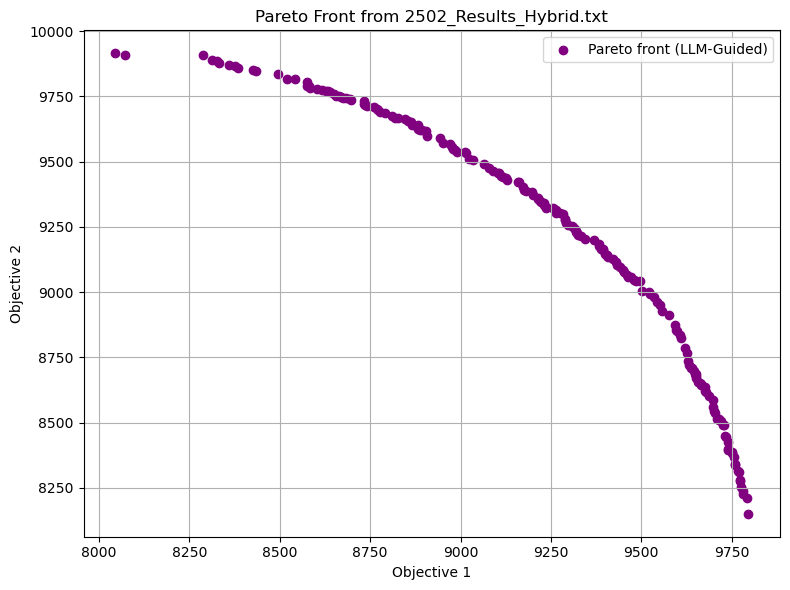


✅ ALL DONE!


In [4]:
# ============================================================================
# CELL 3: Python Strategy Provider and Execution
# Date: 2025-11-05 19:55:01 UTC
# User: samimh23
# ============================================================================

import requests
import json
import matplotlib.pyplot as plt
import time

# ============================================================================
# LLM STRATEGY PROVIDER CLASS
# ============================================================================

class LLMStrategyProvider:
    """
    Provides optimization strategies by querying a local LLM.
    """
    def __init__(self, model_name="llama3:8b"):
        self.model_name = model_name
        self.prompt_template = """Select strategy for knapsack optimization iteration {iteration}/100.

Phase: {phase}

Strategies:
1 = Balanced exploration (early phase, need diversity)
2 = Objective specialization (mid phase, extreme solutions)
3 = Gap filling (always good, improve weak objective)
4 = Aggressive exploitation (late phase, high quality only)
5 = Random perturbation (if stuck)

Reply with ONE number (1-5):"""
        self.url = "http://localhost:11434/api/generate"
        self.call_count = 0

    def reset_for_run(self, run_id):
        """Reset state for new run"""
        print(f"[PYTHON] Strategy provider reset for run {run_id}")

    def _query_llm(self, prompt):
        """Query the LLM"""
        payload = {
            "model": self.model_name,
            "prompt": prompt,
            "stream": False,
            "options": {"temperature": 0.7, "max_tokens": 10}
        }
        try:
            response = requests.post(self.url, json=payload, timeout=40)
            if response.status_code == 200:
                result = response.json()
                response_text = result.get('response', '')
                for char in response_text:
                    if char.isdigit():
                        return int(char)
                return 1
            else:
                return 1
        except requests.exceptions.RequestException as e:
            print(f"[PYTHON] LLM error: {e}")
            return 1

    def get_strategy_dict(self, iteration):
        """
        Main method called by Cython code
        Returns dict with strategy details
        """
        self.call_count += 1
        
        # Calculate phase
        if iteration < 20:
            phase = "Early"
        elif iteration < 60:
            phase = "Mid"
        elif iteration < 90:
            phase = "Late"
        else:
            phase = "Final"

        # Query LLM
        prompt = self.prompt_template.format(iteration=iteration, phase=phase)
        strategy_code = self._query_llm(prompt)
        
        # Determine parameters
        target_obj = 0 if strategy_code == 2 else 0
        threshold = 0.9 if strategy_code == 4 else 0.9

        return {
            'code': strategy_code,
            'target_obj': target_obj,
            'threshold': threshold
        }

# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================

def dominates(a, b):
    """Check if a dominates b (maximization)"""
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_true_pareto_front(points):
    """Extract Pareto front from points"""
    pareto = []
    for i, p in enumerate(points):
        dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                dominated = True
                break
        if not dominated:
            pareto.append(p)
    return pareto

def plot_pareto_front(filename, title_suffix=""):
    """Plot Pareto front from file"""
    points = []
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    points.append([float(x) for x in line.split()])
                except:
                    pass
    
    if not points:
        print(f"No data to plot in {filename}")
        return
    
    pareto = get_true_pareto_front(points)
    xs, ys = zip(*pareto)
    
    plt.figure(figsize=(8,6))
    plt.scatter(xs, ys, color='purple', label=f"Pareto front {title_suffix}")
    plt.xlabel("Objective 1")
    plt.ylabel("Objective 2")
    plt.title(f"Pareto Front from {filename}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def report_pareto_stats(filename):
    """Report statistics about Pareto front"""
    points = []
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    points.append([float(x) for x in line.split()])
                except:
                    pass
    
    total_points = len(points)
    pareto_front = get_true_pareto_front(points)
    num_pareto = len(pareto_front)
    
    print(f"{filename}:")
    print(f"  Total points: {total_points}")
    print(f"  Pareto-optimal points: {num_pareto}")

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    print("=" * 70)
    print("HYBRID LLM-MOACP EXECUTION")
    print("Date: 2025-11-05 19:55:01 UTC")
    print("User: samimh23")
    print("=" * 70)
    
    # Create strategy provider
    llm_provider = LLMStrategyProvider(model_name="llama3:8b")
    
    # Run hybrid MOACP
    print("\n--- Starting LLM-guided MOACP execution ---\n")
    
    start_time = time.time()
    
    run_hybrid_moacp(
        instance_file=b"250.2.txt",
        weights_file=b"Weights_2obj_FQ200.txt",
        nbitems=250,
        num_objectives=2,
        output_file="2502_Results_Hybrid.txt",
        strategy_provider=llm_provider
    )
    
    elapsed = time.time() - start_time
    
    print(f"\n--- Execution finished in {elapsed:.1f}s ({elapsed/60:.2f} min) ---\n")
    
    # Report statistics
    print("\n--- Results Statistics ---")
    report_pareto_stats("2502_Results_Hybrid.txt")
    
    # Plot results
    print("\n--- Plotting results ---")
    plot_pareto_front("2502_Results_Hybrid.txt", title_suffix="(LLM-Guided)")
    
    print("\n✅ ALL DONE!")

In [5]:
# Compare with baseline
print("\n--- Comparison with Baseline ---")
report_pareto_stats("2502_ResultsMD.txt")  # Baseline
report_pareto_stats("2502_Results_Hybrid.txt")  # Hybrid


--- Comparison with Baseline ---
2502_ResultsMD.txt:
  Total points: 1413
  Pareto-optimal points: 212
2502_Results_Hybrid.txt:
  Total points: 1165
  Pareto-optimal points: 190


In [1]:
import matplotlib.pyplot as plt

# --- Helper Functions (to find the true Pareto front) ---

def dominates(a, b):
    """
    Returns True if solution 'a' dominates solution 'b'.
    Assumes both objectives are to be maximized.
    """
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_true_pareto_front(points):
    """
    Filters a list of points to return only the non-dominated ones (the true Pareto front).
    """
    pareto_front = []
    for i, p in enumerate(points):
        is_dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                is_dominated = True
                break
        if not is_dominated:
            pareto_front.append(p)
    return pareto_front

# --- Main Plotting Function ---

def plot_comparison_pareto(filename1, filename2, title1, title2):
    """
    Reads two result files, extracts their Pareto fronts, and plots them on the same graph.

    Args:
        filename1 (str): Path to the first result file (e.g., the baseline).
        filename2 (str): Path to the second result file (e.g., the hybrid).
        title1 (str): A descriptive name for the first algorithm (for the legend).
        title2 (str): A descriptive name for the second algorithm (for the legend).
    """
    # --- Read and process the first file ---
    points1 = []
    with open(filename1, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    points1.append([float(x) for x in line.split()])
                except ValueError:
                    # Skip lines that are not valid numbers
                    pass
    pareto1 = get_true_pareto_front(points1)
    xs1, ys1 = zip(*pareto1) # Unzip the list of (x, y) pairs into two lists

    # --- Read and process the second file ---
    points2 = []
    with open(filename2, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    points2.append([float(x) for x in line.split()])
                except ValueError:
                    pass
    pareto2 = get_true_pareto_front(points2)
    xs2, ys2 = zip(*pareto2) # Unzip the list of (x, y) pairs into two lists

    # --- Create the plot ---
    plt.figure(figsize=(10, 8))

    # Plot the first Pareto front
    plt.scatter(xs1, ys1, color='blue', alpha=0.7, label=f'{title1} ({len(pareto1)} points)', marker='o')

    # Plot the second Pareto front
    plt.scatter(xs2, ys2, color='red', alpha=0.7, label=f'{title2} ({len(pareto2)} points)', marker='x')

    # Add labels, title, and legend
    plt.xlabel("Objective 1 (Profit 1)")
    plt.ylabel("Objective 2 (Profit 2)")
    plt.title("Pareto Front Comparison")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


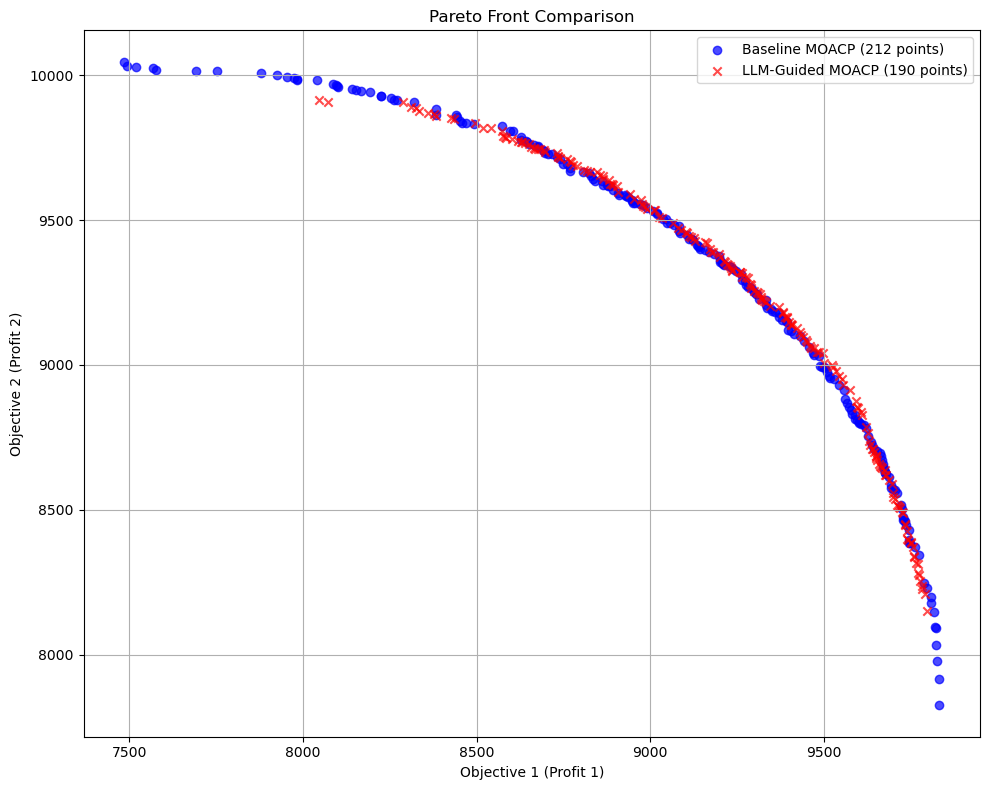

In [2]:
# Call the function with your file names and descriptive titles
plot_comparison_pareto(
    filename1="2502_ResultsMD.txt",
    filename2="2502_Results_Hybrid.txt",
    title1="Baseline MOACP",
    title2="LLM-Guided MOACP"
)